# Detecting Human Emotion from Speech

jacob.schertz, lawrence.winters, josh.parker, durga.sandeep

## Introduction and Problem Definition

In this project, we aim to develop a machine learning model that can recognize human emotion from spoken audio. By enabling machines to comprehend emotional states from voice signals, we can make more human-like and emotionally intelligent AI systems. This capability has potential applications in areas such as AI therapy, emotion-aware assistants and real-time feedback in education. Our focus is on building a foundational model that can classify common emotional states such as happiness, sadness, anger, disgust, fear, and neutral based on patterns in speech.

# Data Preparation and Analysis (Done by jacob.schertz)

In [16]:
#pip install pandas librosa numpy scikit-learn tqdm

## Import Crowd Sourced Emotional Multimodal Actors Dataset (CREMA-D)

In [17]:
import pandas as pd

df = pd.read_excel('Crema-D data.xlsx')
print(df.head())

   Id  Dataset                                        Filepath  \
0   0  CREMA-D  ./dataset/crema-d\AudioWAV\1001_DFA_ANG_XX.wav   
1   1  CREMA-D  ./dataset/crema-d\AudioWAV\1001_DFA_DIS_XX.wav   
2   2  CREMA-D  ./dataset/crema-d\AudioWAV\1001_DFA_FEA_XX.wav   
3   3  CREMA-D  ./dataset/crema-d\AudioWAV\1001_DFA_HAP_XX.wav   
4   4  CREMA-D  ./dataset/crema-d\AudioWAV\1001_DFA_NEU_XX.wav   

              Filename   Ext     Speaker                   Text Gender  Age  \
0  1001_DFA_ANG_XX.wav  .wav  Crema_1001  Don't forget a jacket   Male   51   
1  1001_DFA_DIS_XX.wav  .wav  Crema_1001  Don't forget a jacket   Male   51   
2  1001_DFA_FEA_XX.wav  .wav  Crema_1001  Don't forget a jacket   Male   51   
3  1001_DFA_HAP_XX.wav  .wav  Crema_1001  Don't forget a jacket   Male   51   
4  1001_DFA_NEU_XX.wav  .wav  Crema_1001  Don't forget a jacket   Male   51   

        Race        Accent Intensity/Level  Emotion  
0  Caucasian  Not Hispanic     Unspecified    Anger  
1  Caucasian  Not Hi

## Useful Features to Extract from Audio Samples

### Mel-Frequency Cepstral Coefficients (MFCCs)

- Coefficients that capture the tone quality of an audio signal.
- Each Coefficient gets into more fine detail than the previous.
- Different tones could potentially correlate to different emotions.

### Chroma Features

- Represents the energy of each of the 12 pitch classes.
- Could be useful in detecting melodic speaking patterns that could be connected to certain emotions.

### Spectral Centroid

- Represents the center of mass in an audio spectrum. (Where there is a heavier sound)
- Certain emotions would have higher or lower energy, which would result in a higher or lower centroids.

### Zero Crossing Rate (ZCR)

- The rate in which an audio signal changes sign.
- Different frequencies would help differentiate between high and low energy emotions.

### Root Mean Square Energy (RMSE)

- Measure of how loud the audio signal based on the amplitude.

In [18]:
import librosa
import numpy as np
from tqdm import tqdm

def extract_features(file_path, sr=22050, duration=3):
        y, sr = librosa.load(file_path, sr=sr, duration=duration)
        features = []

        # MFCCs
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        features.extend(np.mean(mfcc, axis=1))

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend(np.mean(chroma, axis=1))

        # Spectral Centroid
        spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        features.extend(np.mean(spec_centroid, axis=1))

        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        features.extend(np.mean(zcr, axis=1))

        # RMSE
        rmse = librosa.feature.rms(y=y)
        features.extend(np.mean(rmse, axis=1))

        return features

feature_list = []

df['Filepath'] = df['Filepath'].str.replace('\\', '/', regex=False)
for path in tqdm(df['Filepath']):
    features = extract_features(path)
    feature_list.append(features)

# Add features to dataframe
features_df = pd.DataFrame(feature_list)

display(features_df)

C:\Users\jacob\anaconda3\envs\newenv\Lib\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 7442/7442 [04:24<00:00, 28.17it/s]


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,-341.988922,120.799965,-9.834449,39.606232,-2.239531,13.864772,-18.852041,-2.982337,-11.125524,-2.109577,...,0.288219,0.329614,0.386679,0.396047,0.617636,0.620851,0.437260,1516.157973,0.080581,0.040486
1,-388.461945,133.882111,-17.753073,53.109615,-0.516854,22.838816,-23.992502,7.696455,-11.807550,-1.607504,...,0.306961,0.307175,0.323721,0.367458,0.534498,0.707096,0.536642,1457.589671,0.069094,0.015566
2,-352.208435,115.791069,-3.415168,32.881832,5.439893,11.282278,-16.918011,-0.038774,-7.281857,-3.811908,...,0.336156,0.357384,0.440763,0.429834,0.593658,0.661425,0.374865,1421.898267,0.062765,0.044071
3,-337.839569,120.109604,-12.691747,39.687588,4.412653,10.073730,-21.633324,0.222240,-10.304431,-6.165375,...,0.444185,0.333523,0.292387,0.348992,0.550748,0.682766,0.430453,1481.793207,0.063893,0.040840
4,-368.175568,124.364937,-4.643919,39.390564,6.951158,12.446601,-13.139218,-2.361498,-10.503442,-4.843659,...,0.299662,0.319028,0.352613,0.385996,0.502990,0.645826,0.538583,1424.198808,0.061546,0.019763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7437,-454.682281,133.600876,11.282866,54.848759,-16.429239,43.725529,-17.856445,16.364075,-10.028722,10.061724,...,0.441198,0.419897,0.465107,0.605179,0.616303,0.615276,0.464612,1616.733265,0.089559,0.008579
7438,-465.707092,127.066902,14.280635,58.876904,-12.683971,44.614468,-17.539865,14.821150,-6.258832,9.735626,...,0.456659,0.500262,0.560922,0.594447,0.577456,0.574559,0.472231,1550.965648,0.072627,0.008366
7439,-410.917206,124.266685,8.617778,52.535904,-10.971675,30.253733,-19.481155,12.302868,-9.710963,9.781964,...,0.385087,0.445588,0.470778,0.495373,0.580830,0.581518,0.407412,1704.955902,0.102575,0.015173
7440,-429.455109,122.096786,19.652607,45.077877,-13.957479,31.799103,-11.164690,10.587568,-8.244925,9.436749,...,0.434873,0.467128,0.487687,0.475373,0.489264,0.565207,0.429408,1667.725824,0.085759,0.011200


In [19]:
# Assign names to each collumn
mfcc_names   = [f'mfcc_{i+1}' for i in range(13)]
chroma_names = [f'chroma_{i+1}' for i in range(12)]
other_names  = ['spectral_centroid', 'zcr', 'rmse']

feature_names = mfcc_names + chroma_names + other_names

# Assign to the DataFrame
features_df.columns = feature_names

df_full = pd.concat([df, features_df], axis=1)


In [20]:
print(df_full.head())

   Id  Dataset                                        Filepath  \
0   0  CREMA-D  ./dataset/crema-d/AudioWAV/1001_DFA_ANG_XX.wav   
1   1  CREMA-D  ./dataset/crema-d/AudioWAV/1001_DFA_DIS_XX.wav   
2   2  CREMA-D  ./dataset/crema-d/AudioWAV/1001_DFA_FEA_XX.wav   
3   3  CREMA-D  ./dataset/crema-d/AudioWAV/1001_DFA_HAP_XX.wav   
4   4  CREMA-D  ./dataset/crema-d/AudioWAV/1001_DFA_NEU_XX.wav   

              Filename   Ext     Speaker                   Text Gender  Age  \
0  1001_DFA_ANG_XX.wav  .wav  Crema_1001  Don't forget a jacket   Male   51   
1  1001_DFA_DIS_XX.wav  .wav  Crema_1001  Don't forget a jacket   Male   51   
2  1001_DFA_FEA_XX.wav  .wav  Crema_1001  Don't forget a jacket   Male   51   
3  1001_DFA_HAP_XX.wav  .wav  Crema_1001  Don't forget a jacket   Male   51   
4  1001_DFA_NEU_XX.wav  .wav  Crema_1001  Don't forget a jacket   Male   51   

        Race  ...  chroma_6  chroma_7  chroma_8  chroma_9  chroma_10  \
0  Caucasian  ...  0.288219  0.329614  0.386679  0.39604

In [21]:
# Print each duplicated row
duplicates = df_full[df_full.duplicated()]
print("Duplicates:\n", duplicates)

Duplicates:
 Empty DataFrame
Columns: [Id, Dataset, Filepath, Filename, Ext, Speaker, Text, Gender, Age, Race, Accent, Intensity/Level, Emotion, mfcc_1, mfcc_2, mfcc_3, mfcc_4, mfcc_5, mfcc_6, mfcc_7, mfcc_8, mfcc_9, mfcc_10, mfcc_11, mfcc_12, mfcc_13, chroma_1, chroma_2, chroma_3, chroma_4, chroma_5, chroma_6, chroma_7, chroma_8, chroma_9, chroma_10, chroma_11, chroma_12, spectral_centroid, zcr, rmse]
Index: []

[0 rows x 41 columns]


In [22]:
# Print each row that contains a missing value
dfMissing = df_full[df_full.isnull().any(axis=1)]
print("Records with Missing Values")
display(dfMissing)

Records with Missing Values


,Id,Dataset,Filepath,Filename,Ext,Speaker,Text,Gender,Age,Race,...,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,chroma_12,spectral_centroid,zcr,rmse


In [23]:
df_full = df_full.drop(columns=["Id", "Dataset", "Filepath", "Filename", "Ext", "Speaker", "Text"])

display(df_full)

,Gender,Age,Race,Accent,Intensity/Level,Emotion,mfcc_1,mfcc_2,mfcc_3,mfcc_4,...,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,chroma_12,spectral_centroid,zcr,rmse
0,Male,51,Caucasian,Not Hispanic,Unspecified,Anger,-341.988922,120.799965,-9.834449,39.606232,...,0.288219,0.329614,0.386679,0.396047,0.617636,0.620851,0.437260,1516.157973,0.080581,0.040486
1,Male,51,Caucasian,Not Hispanic,Unspecified,Disgust,-388.461945,133.882111,-17.753073,53.109615,...,0.306961,0.307175,0.323721,0.367458,0.534498,0.707096,0.536642,1457.589671,0.069094,0.015566
2,Male,51,Caucasian,Not Hispanic,Unspecified,Fear,-352.208435,115.791069,-3.415168,32.881832,...,0.336156,0.357384,0.440763,0.429834,0.593658,0.661425,0.374865,1421.898267,0.062765,0.044071
3,Male,51,Caucasian,Not Hispanic,Unspecified,Happy,-337.839569,120.109604,-12.691747,39.687588,...,0.444185,0.333523,0.292387,0.348992,0.550748,0.682766,0.430453,1481.793207,0.063893,0.040840
4,Male,51,Caucasian,Not Hispanic,Unspecified,Neutral,-368.175568,124.364937,-4.643919,39.390564,...,0.299662,0.319028,0.352613,0.385996,0.502990,0.645826,0.538583,1424.198808,0.061546,0.019763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7437,Female,29,Asian,Not Hispanic,Unspecified,Disgust,-454.682281,133.600876,11.282866,54.848759,...,0.441198,0.419897,0.465107,0.605179,0.616303,0.615276,0.464612,1616.733265,0.089559,0.008579
7438,Female,29,Asian,Not Hispanic,Unspecified,Fear,-465.707092,127.066902,14.280635,58.876904,...,0.456659,0.500262,0.560922,0.594447,0.577456,0.574559,0.472231,1550.965648,0.072627,0.008366
7439,Female,29,Asian,Not Hispanic,Unspecified,Happy,-410.917206,124.266685,8.617778,52.535904,...,0.385087,0.445588,0.470778,0.495373,0.580830,0.581518,0.407412,1704.955902,0.102575,0.015173
7440,Female,29,Asian,Not Hispanic,Unspecified,Neutral,-429.455109,122.096786,19.652607,45.077877,...,0.434873,0.467128,0.487687,0.475373,0.489264,0.565207,0.429408,1667.725824,0.085759,0.011200


### Feature Box Plots

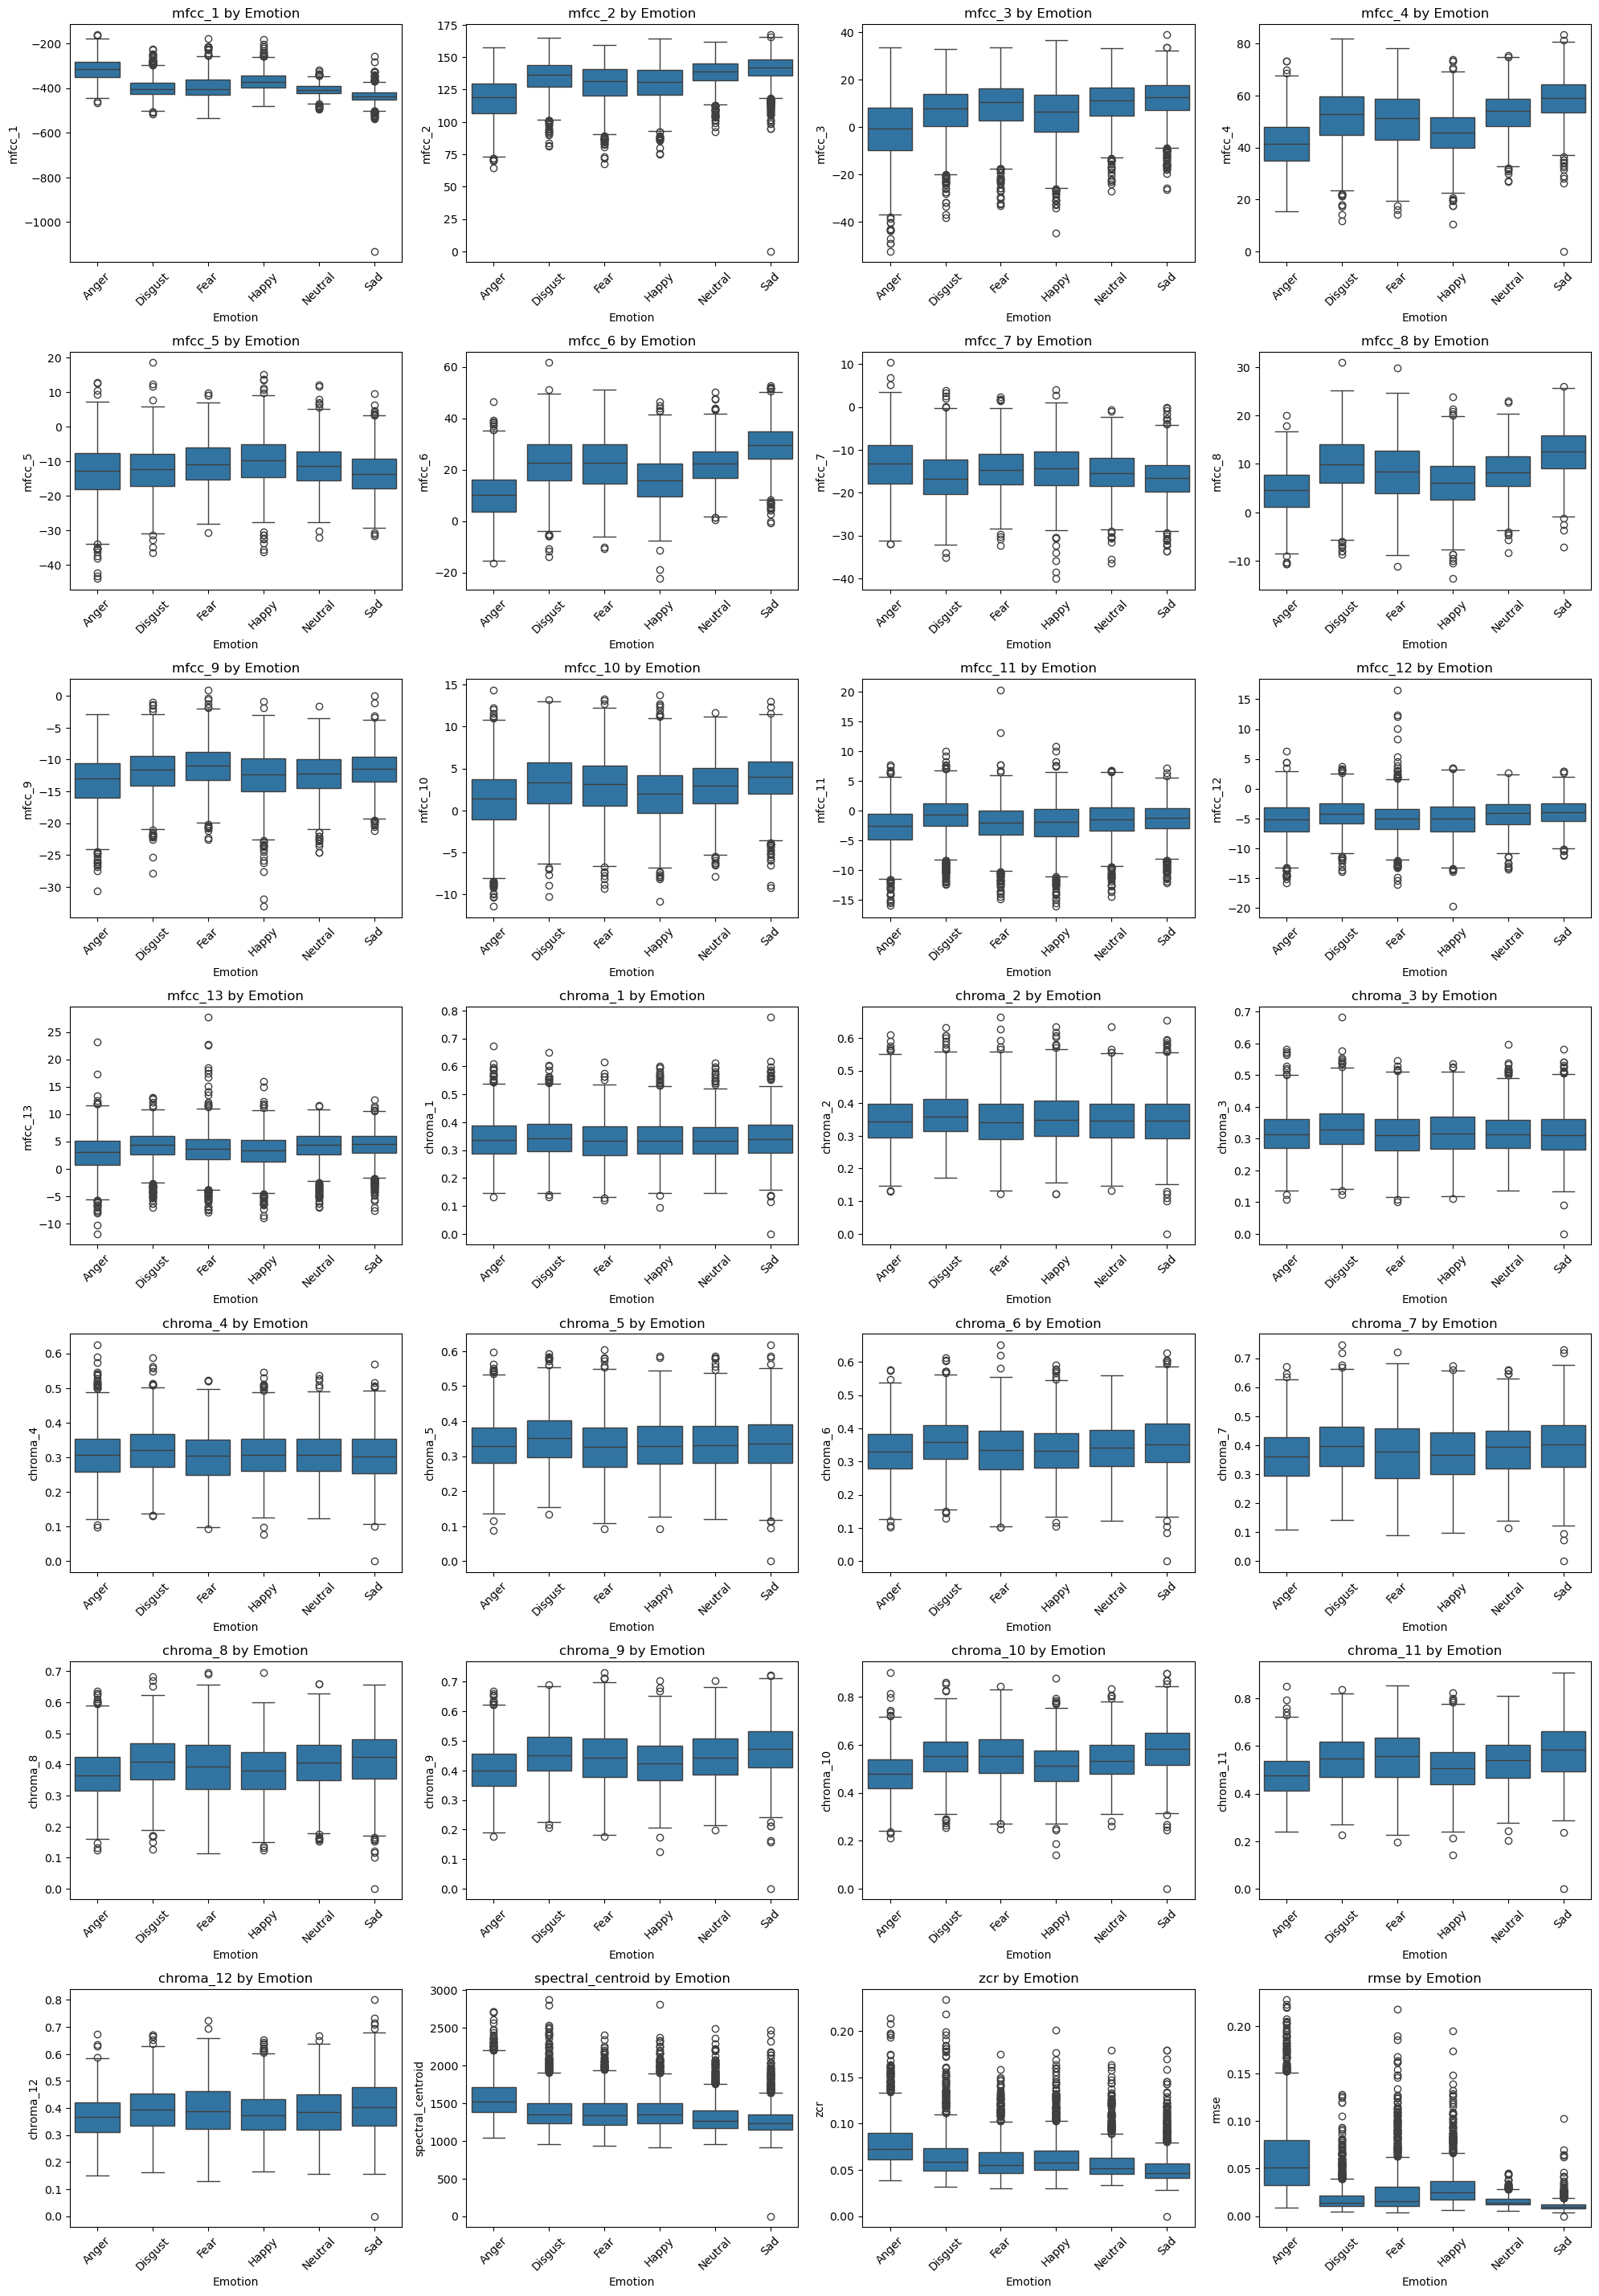

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

num_features = len(feature_names)
rows = (num_features // 4) + 1  # 4 plots per row

plt.figure(figsize=(20, rows * 4))

for i, col in enumerate(feature_names):
    plt.subplot(rows, 4, i + 1)
    sns.boxplot(x='Emotion', y=col, data=df_full)
    plt.title(f'{col} by Emotion')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

These box plots allow us to see trends in how certain features correlate to certain emotions. For example, rmse is used to determine the loudness of the speaker, and we can see a trend where the anger emotion tended to have a higher loudness than the rest, with the sad emotion trending to lower values.

# Model Development

For this project, we chose to use a Random Forest classifier because of its performance capabilities, interpretability, and ease of use. Random Forest is an ensemble model that combines multiple decision trees, which helps reduce overfitting and improves generalization to new data. It handles non-linear relationships well, which is useful given the complexity of audio features like MFCCs and RMSE. Additionally, it has built-in feature importance scores, courtesy of the sklearn library, helping to identify which features most influence emotion detection. When compared to more complex models, Random Forests require minimal preprocessing and are easier to interpret, making them a practical and effective choice for this task.

Random Forest provides a great baseline for most data sets, to compare the performance with something a bit more targeted we also opted to test with a Support Vector Machine (SVM). SVMs work well when dealing with high-dimensional data and especially when there's a lot of features to a relatively small data set. For audio data we can go into the hundreds of acoustic features, and SVMs work off of dot product computations instead of having to deal with massive matrix transformations in other types of classifiers. Additionally SVMs provide a margin with how they split data which for cases like audio that have high overlap across features, helps with generalizability when transferring to testing and real world data.

# Random Forest Model (Done by lawrence.winters)

## Model Preparation

#### Import Libraries

In [25]:
# Import libraries for the random forest ensemble model
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

### Remove Non-Numerical Columns

In [26]:
# Start by dropping the non numerical columns
# Drop non-numeric columns and target from features
feature_columns = df_full.drop(columns=["Gender", "Age", "Race", "Accent", "Intensity/Level", "Emotion"]).columns

X = df_full[feature_columns]
emotion_col = df_full["Emotion"]

# Display the descriptive and target features
display(X)
display(emotion_col)

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,chroma_12,spectral_centroid,zcr,rmse
0,-341.988922,120.799965,-9.834449,39.606232,-2.239531,13.864772,-18.852041,-2.982337,-11.125524,-2.109577,...,0.288219,0.329614,0.386679,0.396047,0.617636,0.620851,0.437260,1516.157973,0.080581,0.040486
1,-388.461945,133.882111,-17.753073,53.109615,-0.516854,22.838816,-23.992502,7.696455,-11.807550,-1.607504,...,0.306961,0.307175,0.323721,0.367458,0.534498,0.707096,0.536642,1457.589671,0.069094,0.015566
2,-352.208435,115.791069,-3.415168,32.881832,5.439893,11.282278,-16.918011,-0.038774,-7.281857,-3.811908,...,0.336156,0.357384,0.440763,0.429834,0.593658,0.661425,0.374865,1421.898267,0.062765,0.044071
3,-337.839569,120.109604,-12.691747,39.687588,4.412653,10.073730,-21.633324,0.222240,-10.304431,-6.165375,...,0.444185,0.333523,0.292387,0.348992,0.550748,0.682766,0.430453,1481.793207,0.063893,0.040840
4,-368.175568,124.364937,-4.643919,39.390564,6.951158,12.446601,-13.139218,-2.361498,-10.503442,-4.843659,...,0.299662,0.319028,0.352613,0.385996,0.502990,0.645826,0.538583,1424.198808,0.061546,0.019763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7437,-454.682281,133.600876,11.282866,54.848759,-16.429239,43.725529,-17.856445,16.364075,-10.028722,10.061724,...,0.441198,0.419897,0.465107,0.605179,0.616303,0.615276,0.464612,1616.733265,0.089559,0.008579
7438,-465.707092,127.066902,14.280635,58.876904,-12.683971,44.614468,-17.539865,14.821150,-6.258832,9.735626,...,0.456659,0.500262,0.560922,0.594447,0.577456,0.574559,0.472231,1550.965648,0.072627,0.008366
7439,-410.917206,124.266685,8.617778,52.535904,-10.971675,30.253733,-19.481155,12.302868,-9.710963,9.781964,...,0.385087,0.445588,0.470778,0.495373,0.580830,0.581518,0.407412,1704.955902,0.102575,0.015173
7440,-429.455109,122.096786,19.652607,45.077877,-13.957479,31.799103,-11.164690,10.587568,-8.244925,9.436749,...,0.434873,0.467128,0.487687,0.475373,0.489264,0.565207,0.429408,1667.725824,0.085759,0.011200


0         Anger
1       Disgust
2          Fear
3         Happy
4       Neutral
         ...   
7437    Disgust
7438       Fear
7439      Happy
7440    Neutral
7441        Sad
Name: Emotion, Length: 7442, dtype: object

### One-Hot Encode the Emotions

In [27]:
# One hot encode the emotions
encoded_y = pd.get_dummies(emotion_col, prefix='Emotion', dtype=int)
print("\nOne-Hot Encoded Table")
display(encoded_y)


One-Hot Encoded Table


,Emotion_Anger,Emotion_Disgust,Emotion_Fear,Emotion_Happy,Emotion_Neutral,Emotion_Sad
0,1,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,1,0,0,0
3,0,0,0,1,0,0
4,0,0,0,0,1,0
...,...,...,...,...,...,...
7437,0,1,0,0,0,0
7438,0,0,1,0,0,0
7439,0,0,0,1,0,0
7440,0,0,0,0,1,0


### Split the data 80 / 20

In [28]:
# Split the data 80 / 20
# Ensure preservation of split proportions using stratify
rand_num = 22
train_X, test_X, train_y, test_y = train_test_split(X, encoded_y, test_size=0.2, 
                                                    stratify=emotion_col, random_state=rand_num)

# Convert one-hot encoded table to label format for training and evaluation
train_y_labels = train_y.idxmax(axis=1).str.replace("Emotion_", "")
test_y_labels = test_y.idxmax(axis=1).str.replace("Emotion_", "")

display(train_X)
display(test_X)
display(train_y_labels)

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,chroma_12,spectral_centroid,zcr,rmse
7213,-430.712982,116.716805,7.271327,45.498604,-8.323478,32.433243,-14.164117,10.921101,-5.934484,9.046833,...,0.339762,0.301972,0.303528,0.424719,0.706137,0.733999,0.479857,1625.699698,0.070564,0.012542
6833,-451.996765,140.964020,8.992121,50.519115,-12.097613,32.267258,-20.431404,11.032178,-8.537960,-0.216132,...,0.371630,0.406971,0.402193,0.387580,0.480301,0.519096,0.393965,1347.611972,0.061460,0.009702
6605,-390.146515,139.843491,-0.672134,51.774429,-14.973714,22.480213,-16.322891,3.930290,-6.865414,7.652049,...,0.366462,0.551772,0.595436,0.433834,0.417013,0.472690,0.346871,1331.770842,0.055334,0.014187
5317,-189.190018,126.342812,-40.304497,25.515263,-27.292297,-0.050326,-16.688896,7.233459,-17.609634,0.924541,...,0.185300,0.300698,0.280554,0.352541,0.447474,0.482983,0.440189,1608.641344,0.088246,0.175778
549,-337.674805,118.148041,20.014254,50.760616,-19.875341,4.871121,-9.241743,-0.709311,-11.229259,5.222212,...,0.294691,0.302810,0.290992,0.443531,0.512536,0.368504,0.220177,1401.137441,0.062087,0.053220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6631,-393.865417,118.702126,0.564164,38.555313,-18.416321,25.996870,-17.825661,9.837864,-6.279683,4.991510,...,0.355607,0.403546,0.413173,0.498209,0.490473,0.549116,0.507473,1667.407417,0.076410,0.021109
7112,-455.838257,142.246078,17.476759,62.701836,-13.619969,35.562134,-13.335678,12.956059,-14.439696,3.418233,...,0.441071,0.442402,0.459503,0.492190,0.515014,0.585689,0.508823,1252.897324,0.050701,0.009507
7141,-499.915833,151.197906,25.930759,55.727798,-5.560360,39.062576,-16.575390,14.230039,-7.300007,0.839684,...,0.491528,0.451255,0.489073,0.579351,0.617484,0.487784,0.366983,934.201120,0.030503,0.007261
5579,-264.756134,118.248055,-2.565212,41.798084,-1.493506,0.268887,-9.075442,-0.162672,-18.097492,-2.519939,...,0.341757,0.407191,0.302213,0.269471,0.343359,0.358703,0.180033,1256.606715,0.046903,0.138318


,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,chroma_12,spectral_centroid,zcr,rmse
1980,-399.608459,142.404633,-1.503052,60.100067,-9.347205,22.788845,-17.372541,9.916540,-16.189003,5.868448,...,0.337763,0.343691,0.376481,0.485383,0.524860,0.315809,0.194096,1228.375351,0.046147,0.015433
1464,-405.333710,130.925568,3.003783,60.330208,-4.200159,25.232191,-18.866787,9.104741,-13.159167,4.969098,...,0.326614,0.311703,0.385105,0.504026,0.604820,0.630121,0.435187,1401.230230,0.064578,0.012116
1132,-326.834930,115.789917,3.566031,47.989895,-15.153596,15.033005,-15.400806,8.582323,-16.905262,1.525930,...,0.314457,0.294443,0.423411,0.459841,0.563600,0.462103,0.327574,1779.841834,0.111536,0.039509
47,-389.767975,139.997223,-10.512038,45.029190,-12.856545,24.701750,-17.837069,7.114164,-13.664621,-4.265838,...,0.399863,0.322136,0.368931,0.429502,0.683726,0.671415,0.377222,1488.473884,0.075445,0.015217
264,-485.496399,137.328461,0.251444,54.771519,-7.170846,33.087852,-17.231340,15.448249,-9.064622,-0.638725,...,0.341121,0.427217,0.461360,0.518420,0.805005,0.514189,0.291400,1302.962396,0.040678,0.004556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6209,-391.739075,135.349625,-2.238954,48.409607,-18.441465,23.839779,-17.214731,12.268195,-14.115870,4.704160,...,0.259655,0.332903,0.453417,0.492442,0.437226,0.419522,0.350629,1784.657901,0.113499,0.015961
2781,-230.915375,87.462700,-13.877497,29.427410,-14.550448,7.300072,-9.352617,3.706769,-13.586180,3.204046,...,0.513000,0.422450,0.335646,0.398738,0.480778,0.400340,0.319639,1667.757900,0.079205,0.162222
5925,-309.661713,128.312408,-10.114391,35.663818,-12.999295,2.885743,10.413223,-6.704691,-12.856664,3.231623,...,0.266774,0.337970,0.302810,0.309878,0.461557,0.681849,0.524416,1341.700717,0.058384,0.065172
3180,-468.285339,153.145920,-0.384157,74.115280,-20.138363,40.828712,-29.559767,20.380838,-11.337335,6.450624,...,0.391926,0.489760,0.469805,0.453602,0.641968,0.742610,0.536082,1270.228651,0.044134,0.005735


7213      Happy
6833    Disgust
6605    Disgust
5317      Anger
549       Anger
         ...   
6631    Disgust
7112    Neutral
7141        Sad
5579      Anger
5122        Sad
Length: 5953, dtype: object

## Random Forest Model Development

### Select the Best Criterion for the Decision Trees

In [29]:
# Create two decision tree models for entropy and gini to see how both perform
gini = DecisionTreeClassifier(criterion='gini', random_state=rand_num)
entropy = DecisionTreeClassifier(criterion='entropy', random_state=rand_num)

# Use cv scoring to determine accuracy
gini_score = cross_val_score(gini, train_X, train_y_labels, cv=5)
entropy_score = cross_val_score(entropy, train_X, train_y_labels, cv=5)

# Check the mean and std dev for both trees
gini_mean = gini_score.mean()
gini_std = gini_score.std()

entropy_mean = entropy_score.mean()
entropy_std = entropy_score.std()

# Compare the mean of the cv_scores, factoring in the std. deviation
print(f"Gini Cross-Validation Accuracy: {gini_mean:.4f} +- {gini_std:.4f}")
print(f"Entropy Cross-Validation Accuracy: {entropy_mean:.4f} +- {entropy_std:.4f}")

# Get the best criterion
best_criterion = 'gini'
if (gini_mean - gini_std) < (entropy_mean - entropy_std):
    best_criterion = 'entropy'
print("Best criterion based on accuracy from cross validation:", best_criterion)

Gini Cross-Validation Accuracy: 0.3281 +- 0.0081
Entropy Cross-Validation Accuracy: 0.3188 +- 0.0045
Best criterion based on accuracy from cross validation: gini


### Analyze the Best Number of Estimators

In [30]:
best_accuracy = 0
best_n = 0
n_samples = [5, 10, 50, 100, 200]
for n in n_samples:
    # Use the n sample on the RandomForestClassifier
    forest = RandomForestClassifier(n_estimators=n, criterion=best_criterion, random_state=rand_num)
    forest.fit(train_X, train_y_labels)
    start = time.time()
    acc = accuracy_score(test_y_labels, forest.predict(test_X))
    total_time = time.time() - start
    if (acc > best_accuracy):
        best_n = n
        best_accuracy = acc
    
    print(f"n_estimators={n}, Test Accuracy={acc:.4f}, Execution Time = {total_time:.4f}")

print(f"Highest accuracy corresponds to {best_n} estimators in the random forest")

n_estimators=5, Test Accuracy=0.3559, Execution Time = 0.0087
n_estimators=10, Test Accuracy=0.3956, Execution Time = 0.0098
n_estimators=50, Test Accuracy=0.4466, Execution Time = 0.0287
n_estimators=100, Test Accuracy=0.4486, Execution Time = 0.0683
n_estimators=200, Test Accuracy=0.4506, Execution Time = 0.1228
Highest accuracy corresponds to 200 estimators in the random forest


### Best Random Forest Model

In [31]:
# Make the random forest classifer using the gini impurity criterion
random_forest = RandomForestClassifier(n_estimators=best_n, criterion=best_criterion, random_state=rand_num)
random_forest.fit(train_X, train_y_labels)

RandomForestClassifier(n_estimators=200, random_state=22)

### Comparison between Random Forest and Single Decision Trees

In [32]:
# Display the accuracy between the three models
pred_y = random_forest.predict(test_X)

gini.fit(train_X, train_y_labels)
entropy.fit(train_X, train_y_labels)

gini_pred = gini.predict(test_X)
entropy_pred = entropy.predict(test_X)

print("Gini Tree Accuracy:", accuracy_score(test_y_labels, gini_pred))
print("Entropy Tree Accuracy:", accuracy_score(test_y_labels, entropy_pred))
print("Random Forest Accuracy:", accuracy_score(test_y_labels, pred_y))

Gini Tree Accuracy: 0.33445265278710545
Entropy Tree Accuracy: 0.3404969778374748
Random Forest Accuracy: 0.4506380120886501


### Classification Report and Confusion Matrix

In [33]:
print("Classification Report:\n")
print(classification_report(test_y_labels, pred_y))

print("Confusion Matrix:\n")
print(confusion_matrix(test_y_labels, pred_y))

Classification Report:

              precision    recall  f1-score   support

       Anger       0.60      0.71      0.65       254
     Disgust       0.38      0.30      0.33       254
        Fear       0.43      0.22      0.29       254
       Happy       0.36      0.38      0.37       254
     Neutral       0.36      0.49      0.42       218
         Sad       0.52      0.62      0.57       255

    accuracy                           0.45      1489
   macro avg       0.44      0.45      0.44      1489
weighted avg       0.44      0.45      0.44      1489

Confusion Matrix:

[[180  12   3  48  10   1]
 [ 33  75   9  42  48  47]
 [ 32  24  56  47  40  55]
 [ 54  30  23  96  41  10]
 [  0  35  15  30 106  32]
 [  0  20  24   6  47 158]]


### Feature Importance in the Model

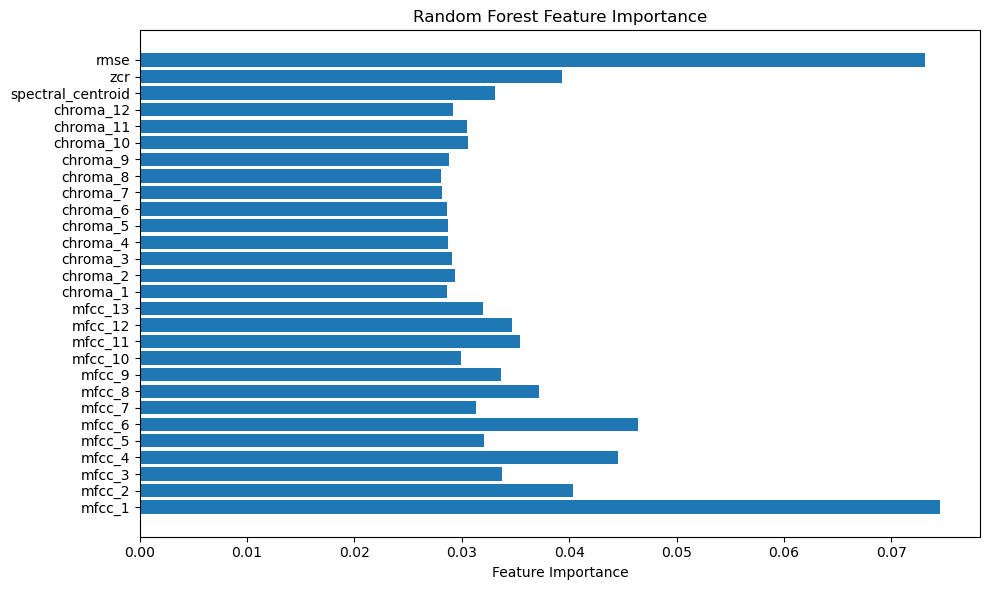

In [34]:
# Showcase a feature importance plot
importances = random_forest.feature_importances_
feat_names = train_X.columns

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

The feature importance plot shows that the rmse, mfcc_6, and mfcc_1 were the most important features to the random forest. RMSE (Root Mean Square Energy) is a measure of the intensity or loudness of the audio signal over time. MFCCs (Mel Frequency Cepstral Coefficients) are features that describe timbre or the quality of the sound. MFCC_1 is the first coefficient and captures voice tone differences. MFCC_6 detects more subtle inflections in the voice tones.

### Display of Random Forest Tree

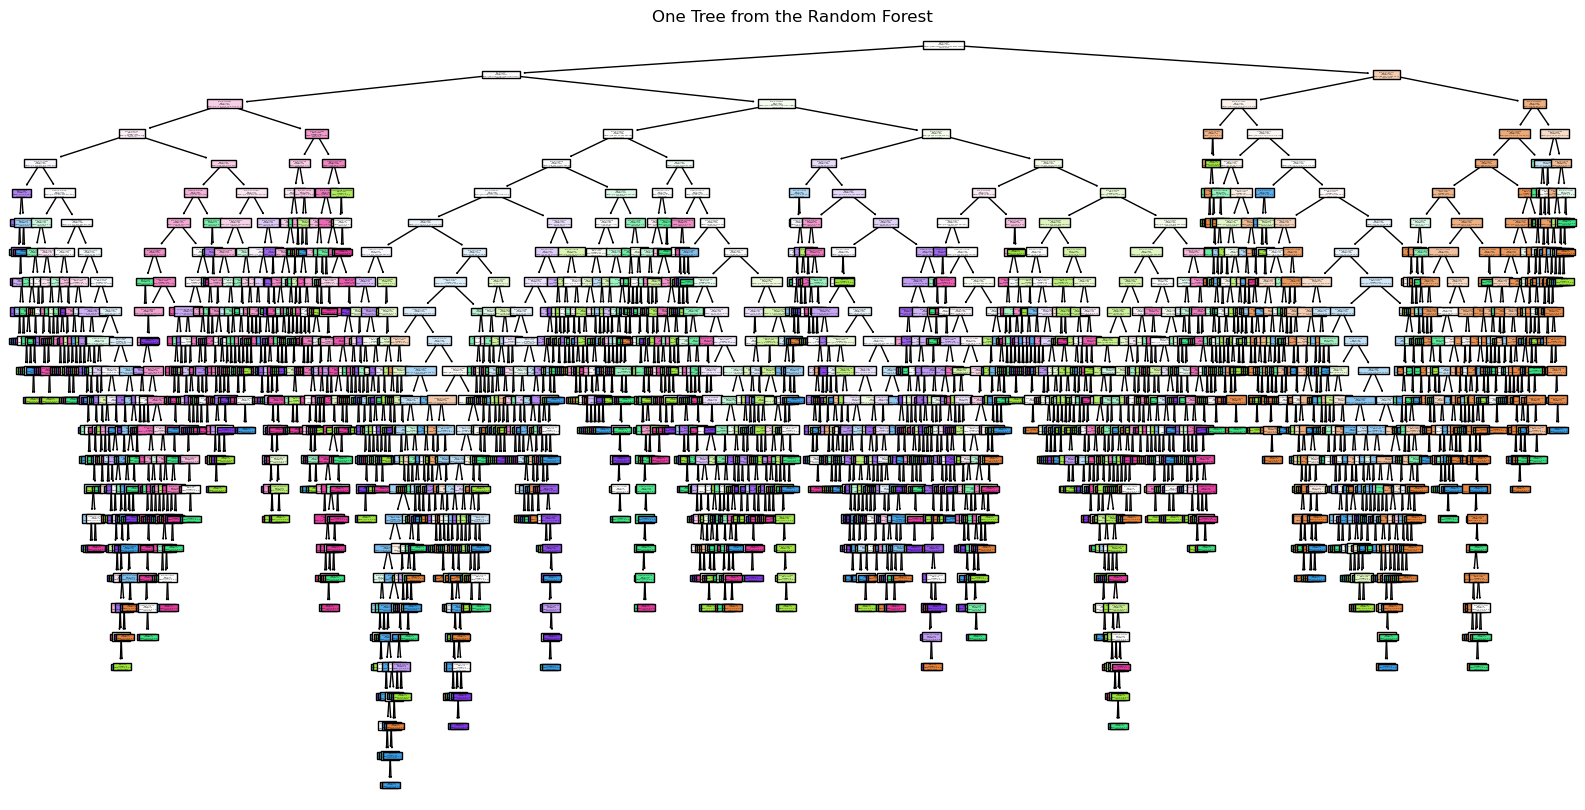

In [35]:
# Showcase one of the trees from the random forest
plt.figure(figsize=(20, 10))
plot_tree(random_forest.estimators_[0], 
          feature_names=train_X.columns, 
          class_names=random_forest.classes_, 
          filled=True)
plt.title("One Tree from the Random Forest")
plt.show()

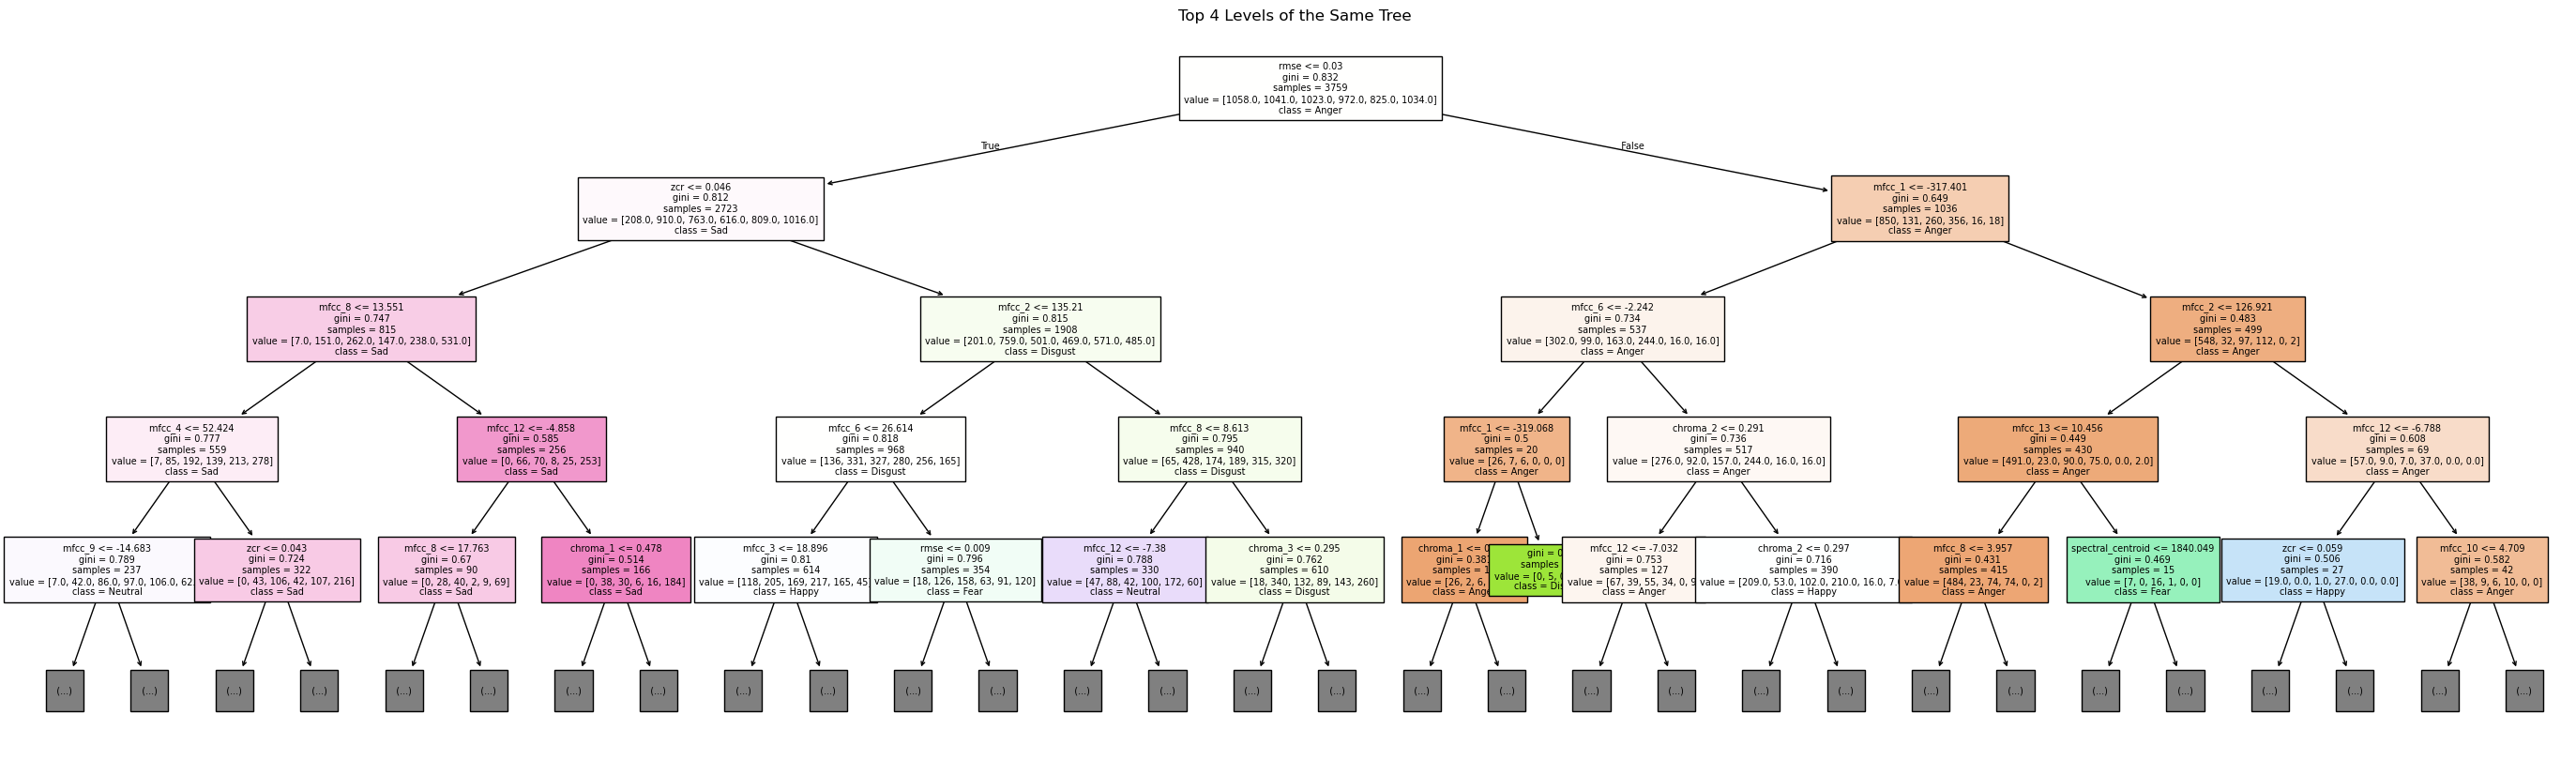

In [36]:
# Show the top 4 levels of the same tree
plt.figure(figsize=(35, 10))
plot_tree(random_forest.estimators_[0], 
          feature_names=train_X.columns, 
          class_names=random_forest.classes_,
          max_depth=4,
          filled=True,
         fontsize=7)
plt.title("Top 4 Levels of the Same Tree")
plt.show()

# Support Vector Machine (Done by: josh.parker)

## Support Vector Machines (SVM) Overview

Support Vector Machines are a supervised learning algorithm used for classification (and regression) tasks. They work by finding a decision boundary—called a **hyperplane**—that maximizes the margin between classes. Key concepts:

- **Hyperplane**: In D-dimensional space, a (D−1)-dimensional flat surface that separates classes.
- **Margin**: The distance between the hyperplane and the nearest data points (the “support vectors”).
- **Support Vectors**: The critical data points that lie closest to the hyperplane and define the margin.
- **Kernel Trick**: Allows SVMs to build non-linear decision boundaries by implicitly mapping data into higher-dimensional spaces without computing those coordinates directly.

Below is a visual example in 2D to illustrate:
- Two classes of points.
- The optimal separating hyperplane.
- Margin boundaries and support vectors.

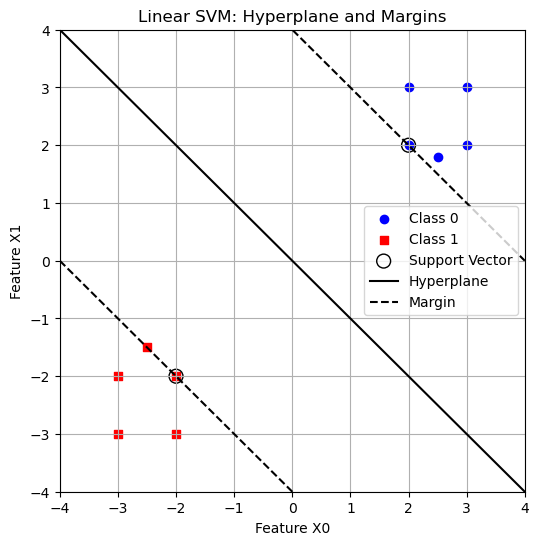

In [37]:
# Hacky code to illustrate SVMs since we can't put images in here

import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm

CLASS0 = [(3, 3), (2, 2), (3, 2), (2, 3), (2.5, 1.8)]
CLASS1 = [(-3, -3), (-2, -2), (-3, -2), (-2, -3), (-2.5, -1.5)]

X = np.array(CLASS0 + CLASS1)
y = np.array([0] * len(CLASS0) + [1] * len(CLASS1))

clf = svm.SVC(kernel='linear', C=1.0)
clf.fit(X, y)

w = clf.coef_[0]
b = clf.intercept_[0]

m = -w[0] / w[1]
c = -b / w[1]

norm_w = np.sqrt(w[0]**2 + w[1]**2)
offset = 1 / norm_w * np.sqrt(1 + m**2)

X_LINE     = np.linspace(-4, 4, 200)
Y_HYPER    = m * X_LINE + c
Y_MARGIN_UP = Y_HYPER + offset
Y_MARGIN_DN = Y_HYPER - offset

plt.figure(figsize=(6,6))
for (px, py) in CLASS0:
    plt.scatter(px, py, marker='o', color='blue', label='Class 0')
for (px, py) in CLASS1:
    plt.scatter(px, py, marker='s', color='red', label='Class 1')

SV = clf.support_vectors_
for (svx, svy) in SV:
    plt.scatter(svx, svy, facecolors='none', edgecolors='k', s=100, label='Support Vector')

plt.plot(X_LINE, Y_HYPER,    'k-',  label='Hyperplane')
plt.plot(X_LINE, Y_MARGIN_UP,'k--', label='Margin')
plt.plot(X_LINE, Y_MARGIN_DN,'k--')

handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())
plt.title('Linear SVM: Hyperplane and Margins')
plt.xlabel('Feature X0')
plt.ylabel('Feature X1')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid(True)
plt.show()

## Encode Emotion Labels as Integers

scikit-learn expects numeric target features so we convert our Emotion feature to integers. ie ['Happy', 'Sad'] -> [0,1]

In [38]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = df_full[feature_names].values
y = df_full['Emotion'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'Anger': np.int64(0), 'Disgust': np.int64(1), 'Fear': np.int64(2), 'Happy': np.int64(3), 'Neutral': np.int64(4), 'Sad': np.int64(5)}


## Split Training and Testing Data

Here we do the usual splitting of our data into 80/20 Training to Testing data sets (Note: We are using the newly encoded y)

Again as usual we stratify against the encoded y target features so our training and testing data maintains approximately the same proportion of each label.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=51,
    stratify=y_encoded
)

## Training the Baseline SVM

1. First we need to scale our data
    - SVMs rely on distances to make their decisions so if we have different features one with a range of [0,1] and another from [0,10000] we're obviously going to run into issues where the feature with the larger scale is going to dominate the decision.
    - We then fit the scaler to the training and test data. We do this after splitting to avoid data leakage between the two datasets.
2. Now we train our baseline SVM to get a starting point to work from
    - We originally tried with both linear and RBF and RBF outperforms in this default case so we'll start with that. This is as expected since we have fairly noisy data that isn't going to have nice linear seperability.
    - We set the class_wieght to 'balanced' - this is done as a precaution so that the **effective** influence is normalized across each class.
        - If we have classes that are under represented we **increase** the weight that we use when dealing with the error. So mistakes in under represented classes are counted more. This helps keep our model from over fitting to a majority class and have worse performance when dealing with a minority class.
3. Lastly we predict on the test set and then evaluate our starting point
    - The classification report shows prediction, recall, and f1 scores per emotion
        - Precision
            - $\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$
            - Of all the samples our model predicted as “Happy” (for example), precision tells us the fraction that were actually Happy.
            - High precision means few “false alarms” or mis-classifications into that class, which is critical if acting on predictions has a cost (ie. triggering an emotional response in an assistant).
        - Recall
            - $\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$
            - Of all the truly “Sad” samples in the test set, recall tells us the fraction our model successfully caught as Sad.
            - High recall means few “misses” of that emotion—important if you need to be sure not to overlook instances of a particular emotion.
        - F1-Score
            - $F_{1} \;=\; 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
            - The f1 score is the harmonic mean of precision and recall combined into a single value
            - A high f1 score indicates a good balance between precision and recall. It’s especially useful when classes are imbalanced or when we care equally about false positives and false negatives.
        - Support
            - The number of true instances of each emotion in the test set (denom of recall)
            - If "Anger" has support 254 that means there are 254 true Anger examples in the test dataset
            - If support is skewed (some emotions have far fewer examples), we need to consider that when observing accuracy that there may be skewing going on. 
              

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm_baseline = SVC(kernel='rbf', class_weight='balanced', random_state=51)
svm_baseline.fit(X_train_scaled, y_train)

y_pred = svm_baseline.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced accuracy: {balanced_accuracy:.2f}\n")

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Classification Report:
              precision    recall  f1-score   support

       Anger       0.62      0.65      0.63       254
     Disgust       0.48      0.32      0.38       255
        Fear       0.43      0.32      0.37       254
       Happy       0.38      0.36      0.37       254
     Neutral       0.38      0.57      0.46       218
         Sad       0.51      0.60      0.55       254

    accuracy                           0.47      1489
   macro avg       0.47      0.47      0.46      1489
weighted avg       0.47      0.47      0.46      1489

Balanced accuracy: 0.47

Confusion Matrix:
[[166  13  12  53   8   2]
 [ 19  82  16  34  56  48]
 [ 30  17  81  39  32  55]
 [ 50  23  35  91  43  12]
 [  3  28  18  17 125  27]
 [  1   8  25   5  63 152]]


## Hyperparameter Tuning with GridSearchCV

For this part we are doing a search over the key SVM hyperparameters to find the combination that maximizes average f1 score

Search Space
- Kernel: We are just searching with rbf here, originally we tested linear as well but there weren't any models using linear that outperformed any of the rbf ones so we dropped it for speed of calculation.
- C: This is the **Regularization** parameter, that controls the tradeoff between margin width and training error.
- gamma: Kernel coefficient for rbf, this controls what's called the "reach" of each support vector.

We then initialize our default classifier in the same manner as we did above.

Then we set up GridSearchCV which does all the permutations of hyperparameters and we set the scoring to f1_macro which will score the models on the macro average of f1 like we discussed previously. We do the usual 5-fold validation on the permutations. 

After that we're going to do the actual computation and at the end we're left with the best combination of parameters that we found in grid.best_estimator_

We then run the best estimator on our test data and dump out the results again. 

Observe that we see a slight increase in accuracy across the board.

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel':    ['rbf'], # Originally included 'linear' here as well but no linear kernels out performed rbf so removed for speed
    'C':         [0.1, 1, 10, 100],
    'gamma':     ['scale', 0.01, 0.1, 1, 10]
}

estimator_baseline = SVC(class_weight='balanced', random_state=51)

grid = GridSearchCV(
    estimator=estimator_baseline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_scaled, y_train)

print("Best parametrs found: ", grid.best_params_)
print("Best cross-val F1-macro: ", grid.best_score_)

best_svm = grid.best_estimator_

y_pred_tuned = best_svm.predict(X_test_scaled)

balanced_accuracy = balanced_accuracy_score(y_test, y_pred_tuned)
print(f"\nBalanced accuracy: {balanced_accuracy:.2f}\n")

print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parametrs found:  {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-val F1-macro:  0.45956440943538013
Balanced accuracy: 0.48


Tuned Model Classification Report:
              precision    recall  f1-score   support

       Anger       0.65      0.69      0.67       254
     Disgust       0.44      0.38      0.41       255
        Fear       0.40      0.40      0.40       254
       Happy       0.41      0.37      0.39       254
     Neutral       0.43      0.48      0.45       218
         Sad       0.53      0.57      0.55       254

    accuracy                           0.48      1489
   macro avg       0.48      0.48      0.48      1489
weighted avg       0.48      0.48      0.48      1489



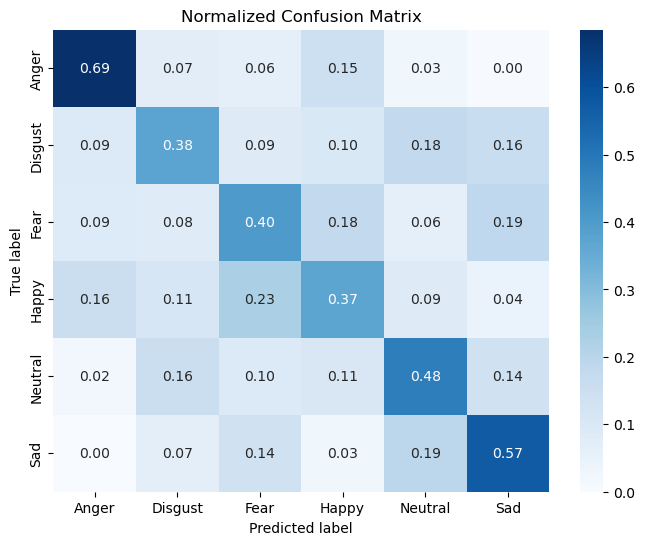

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred_tuned)

conf_matrix_float = conf_matrix.astype(float)

row_sums = conf_matrix_float.sum(axis=1)

conf_matrix_normalized = np.zeros_like(conf_matrix_float)
for i in range(conf_matrix_float.shape[0]):
    if row_sums[i] > 0:
        conf_matrix_normalized[i, :] = conf_matrix_float[i, :] / row_sums[i]
    else:
        conf_matrix_normalized[i, :] = 0

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix_normalized, annot=True, fmt='.2f', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Normalized Confusion Matrix')
plt.show()

# Evaluation and Validation (Done by durga.sandeep)

# Confusion Matrix

### Confusion Matrix for Random Forest

Classification Report:

              precision    recall  f1-score   support

       Anger       0.60      0.71      0.65       254
     Disgust       0.38      0.30      0.33       254
        Fear       0.43      0.22      0.29       254
       Happy       0.36      0.38      0.37       254
     Neutral       0.36      0.49      0.42       218
         Sad       0.52      0.62      0.57       255

    accuracy                           0.45      1489
   macro avg       0.44      0.45      0.44      1489
weighted avg       0.44      0.45      0.44      1489

Balanced accuracy: 0.45

Confusion Matrix:



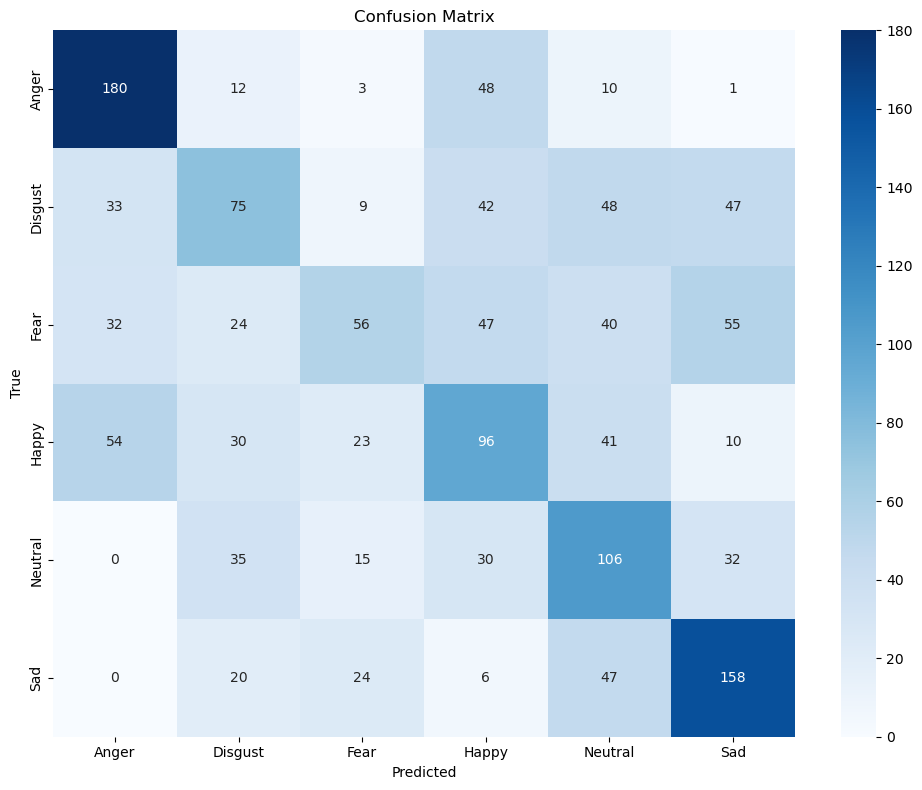

In [43]:
pred_y = random_forest.predict(test_X)

print("Classification Report:\n")
print(classification_report(test_y_labels, pred_y))

balanced_accuracy = balanced_accuracy_score(test_y_labels, pred_y)
print(f"Balanced accuracy: {balanced_accuracy:.2f}\n")


print("Confusion Matrix:\n")
#print(confusion_matrix(test_y, pred_y))


# Generate the confusion matrix
cm = confusion_matrix(test_y_labels, pred_y)

# Create a figure and axis
plt.figure(figsize=(10, 8))

# Draw the heatmap with seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=random_forest.classes_,
           yticklabels=random_forest.classes_)

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# Show the plot
plt.tight_layout()
plt.show()





### Confusion Matrix for SVM (SUPPORT VECTOR MACHINE)

Classification Report:
              precision    recall  f1-score   support

       Anger       0.62      0.65      0.63       254
     Disgust       0.48      0.32      0.38       255
        Fear       0.43      0.32      0.37       254
       Happy       0.38      0.36      0.37       254
     Neutral       0.38      0.57      0.46       218
         Sad       0.51      0.60      0.55       254

    accuracy                           0.47      1489
   macro avg       0.47      0.47      0.46      1489
weighted avg       0.47      0.47      0.46      1489

Balanced accuracy: 0.47



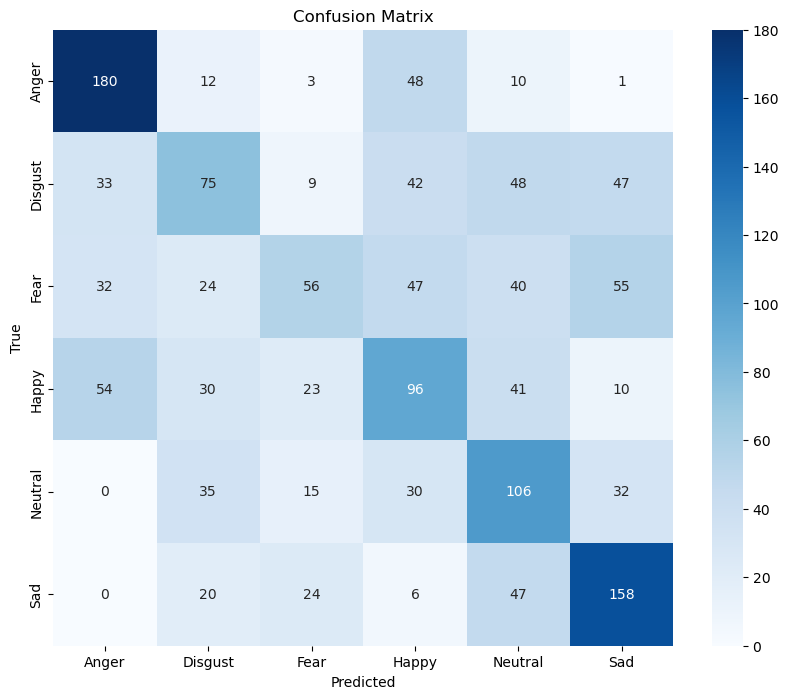

In [44]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm_baseline = SVC(kernel='rbf', class_weight='balanced', random_state=51)
svm_baseline.fit(X_train_scaled, y_train)

y_pred = svm_baseline.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced accuracy: {balanced_accuracy:.2f}\n")

#print("Confusion Matrix:")
#cm = confusion_matrix(y_test, y_pred)
#print(cm)

# Add colored confusion matrix visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()





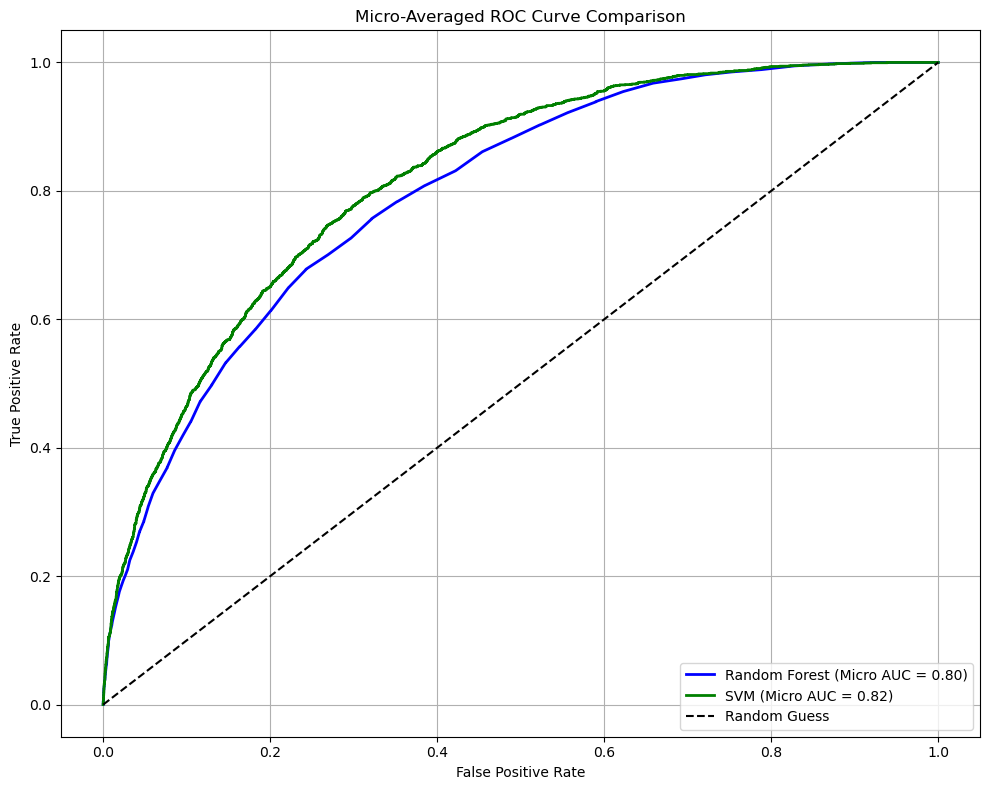

Random Forest:
  Accuracy: 0.45141065830721006
  Balanced Accuracy: 0.45293441336807394
  Macro-AUC: 0.7839953044958662

SVM (Scaled & Balanced):
  Accuracy: 0.4702194357366771
  Balanced Accuracy: 0.4721806105522796
  Macro-AUC: 0.8093240969264005

Classification Report - Random Forest:
              precision    recall  f1-score   support

       Anger       0.58      0.72      0.64       359
     Disgust       0.38      0.29      0.33       386
        Fear       0.38      0.23      0.29       371
       Happy       0.37      0.38      0.38       378
     Neutral       0.40      0.45      0.43       353
         Sad       0.51      0.64      0.57       386

    accuracy                           0.45      2233
   macro avg       0.44      0.45      0.44      2233
weighted avg       0.44      0.45      0.44      2233


Classification Report - SVM:
              precision    recall  f1-score   support

       Anger       0.62      0.69      0.65       359
     Disgust       0.38      

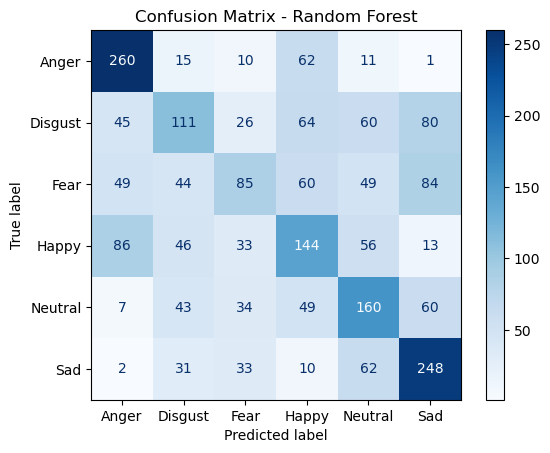

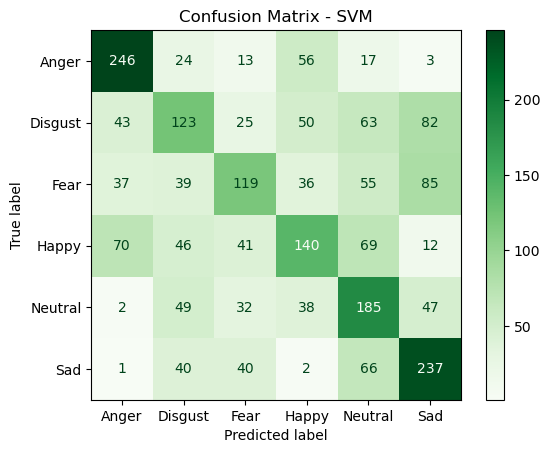

In [45]:
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_curve, auc, accuracy_score, balanced_accuracy_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Prepare features and labels
X = df_full[feature_columns]
y = df_full["Emotion"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
model1 = RandomForestClassifier(random_state=42)
model1.fit(X_train, y_train)

# Train SVM with scaling and balanced class weight
model2 = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=51)
model2.fit(X_train_scaled, y_train)

# Binarize true labels
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))

# Predict probabilities
y_score1 = model1.predict_proba(X_test)
y_score2 = model2.predict_proba(X_test_scaled)

# ROC curves - micro-average
fpr1, tpr1, _ = roc_curve(y_test_bin.ravel(), y_score1.ravel())
roc_auc1 = auc(fpr1, tpr1)

fpr2, tpr2, _ = roc_curve(y_test_bin.ravel(), y_score2.ravel())
roc_auc2 = auc(fpr2, tpr2)

# Macro-average AUC
roc_auc_macro1 = roc_auc_score(y_test_bin, y_score1, average='macro', multi_class='ovr')
roc_auc_macro2 = roc_auc_score(y_test_bin, y_score2, average='macro', multi_class='ovr')

# Plot ROC Curves
plt.figure(figsize=(10, 8))
plt.plot(fpr1, tpr1, lw=2, label=f'Random Forest (Micro AUC = {roc_auc1:.2f})', color='blue')
plt.plot(fpr2, tpr2, lw=2, label=f'SVM (Micro AUC = {roc_auc2:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-Averaged ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Predictions
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test_scaled)

# Metrics
print("Random Forest:")
print("  Accuracy:", accuracy_score(y_test, pred1))
print("  Balanced Accuracy:", balanced_accuracy_score(y_test, pred1))
print("  Macro-AUC:", roc_auc_macro1)

print("\nSVM (Scaled & Balanced):")
print("  Accuracy:", accuracy_score(y_test, pred2))
print("  Balanced Accuracy:", balanced_accuracy_score(y_test, pred2))
print("  Macro-AUC:", roc_auc_macro2)

# Classification reports
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, pred1, target_names=label_encoder.classes_))

print("\nClassification Report - SVM:")
print(classification_report(y_test, pred2, target_names=label_encoder.classes_))

# Confusion Matrices
ConfusionMatrixDisplay.from_predictions(y_test, pred1, display_labels=label_encoder.classes_, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, pred2, display_labels=label_encoder.classes_, cmap='Greens')
plt.title("Confusion Matrix - SVM")
plt.show()


The following gives us the understanding about the models used in this project

The AUC or the ROC index gives us the following data
   
   Random Forest Classifier --> Model 1 --> AUC = 0.80
    
     The Random Forest model is also performing reasonably well, but not as well as the SVM. It suggests the Random Forest is correct 80% of the time in distinguishing positive from negative samples.
           
   Support Vector Machine --> Model 2 --> AUC = 0.82
   
    This means your SVM model is performing quite well, with a good ability to discriminate between the positive and negative classes. It suggests that the SVM model correctly ranks positive samples higher than negative ones 80% of the time.
    

---------------------------------------------------------------------------------------------------------------------------------
Scalability:

SVM - Scales poorly with number of samples. The Big O complexilty increases with power n on number of samples.

RandomForest - Random Forest can be parallelized, but if the number of trees is very large or the trees are very deep, training time grows.

And both the models are Eager learner.

---------------------------------------------------------------------------------------------------------------------------------
The Efficiency  
    When comparing the AUC we can also say that the Random Forest Classifier will be working good by observing the overall classification performance. A higher AUC indicates that the model has better overall capability to classify both positives and negatives correclty across all thresholds.

    To improve the Efficiency we can used GridSearchCV for the SVM.
    
---------------------------------------------------------------------------------------------------------------------------------




Efficiency

Using the following to bring efficiency into the Random Forest Model 

So, the following are used in the model

1. using the n_jobs = -1 - It maximizes the use of available computational resources, which can significantly speed up training, especially when working with a large dataset.

2. Limiting the depth of the trees - max_depth = 10 - By limiting the depth of trees, you prevent overfitting and make the model more generalizable, which can lead to faster training as each tree grows smaller.Additionally, shallower trees are easier to compute.

3. max_features = "sqrt" - By reducing the number of features considered at each node split, it reduces the computational load of the model.

4. Feature Selection using SelectFromModel - By selecting only the most important features, it reduces the number of features the model needs to train on, thus speeding up training and reducing the risk of overfitting.




In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectFromModel

# Feature engineering: Drop non-numeric columns
feature_columns = df_full.drop(columns=["Gender", "Age", "Race", "Accent", "Intensity/Level", "Emotion"]).columns
X = df_full[feature_columns]
y = df_full["Emotion"]

# Label encoding for emotions
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split (80/20)
rand_num = 22
train_X, test_X, train_y, test_y = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=rand_num)

# Create and fit the Random Forest Classifier with efficiency optimizations
model = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=10,  # Limiting tree depth
    max_features="sqrt",  # Feature subset for splits
    n_jobs=-1,  # Use all CPU cores
    random_state=rand_num
)

model.fit(train_X, train_y)

# Feature selection based on importance
# selector = SelectFromModel(model, threshold="mean", max_features=10)
selector = SelectFromModel(model, threshold="median", max_features=12)
train_X_selected = selector.transform(train_X)
test_X_selected = selector.transform(test_X)

# Re-train model on selected features
model.fit(train_X_selected, train_y)

# Predictions
pred_y = model.predict(test_X_selected)

# Print results
print("Classification Report:\n")
print(classification_report(test_y, pred_y, target_names=label_encoder.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(test_y, pred_y))


C:\Users\jacob\anaconda3\envs\newenv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\jacob\anaconda3\envs\newenv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Classification Report:

              precision    recall  f1-score   support

       Anger       0.60      0.67      0.63       254
     Disgust       0.34      0.26      0.30       254
        Fear       0.41      0.19      0.26       254
       Happy       0.35      0.39      0.37       254
     Neutral       0.32      0.44      0.37       218
         Sad       0.52      0.63      0.57       255

    accuracy                           0.43      1489
   macro avg       0.42      0.43      0.42      1489
weighted avg       0.43      0.43      0.42      1489

Confusion Matrix:

[[171  12   6  54   9   2]
 [ 32  66  10  40  58  48]
 [ 32  24  47  47  54  50]
 [ 52  32  18  99  39  14]
 [  0  34  21  31  97  35]
 [  0  25  12   8  50 160]]


## Attribution

Data from Crowd Sourced Emotional Multimodal Actors Dataset by David Cooper, used under the Open Data Commons Attribution License (ODC-By) v1.0.
https://www.kaggle.com/datasets/ejlok1/cremad

The following study was performed to create the CREMA-D dataset.
Cao H, Cooper DG, Keutmann MK, Gur RC, Nenkova A, Verma R. CREMA-D: Crowd-sourced Emotional Multimodal Actors Dataset. IEEE Trans Affect Comput. 2014 Oct-Dec;5(4):377-390. doi: 10.1109/TAFFC.2014.2336244. PMID: 25653738; PMCID: PMC4313618.